In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# Transformer from Scratch — "Attention is All You Need"
**En → De translation on Multi30k**

Run cells top to bottom. GPU runtime required (Runtime → Change runtime type → T4 GPU).

## Cell 1 — Install dependencies

In [ ]:
!pip install datasets tokenizers sacrebleu --quiet

## Cell 2 — transformer.py
Full model architecture: embeddings, positional encoding, multi-head attention, encoder, decoder, projection, builder.

In [ ]:
# ============================================================
# transformer.py
# ============================================================
import math
import torch
import torch.nn as nn


class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.embedding(x) * (self.d_model ** 0.5)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, seq_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)


class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(d_model))
        self.bias = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True, unbiased=False)
        return self.alpha * (x - mean) / (std + self.eps) + self.bias


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        self.d_model = d_model
        self.h = h
        assert d_model % h == 0
        self.d_k = d_model // h
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)

    @staticmethod
    def attention(Q, K, V, d_k, mask=None):
        scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        scores = torch.softmax(scores, dim=-1)
        return scores @ V, scores

    def forward(self, q, k, v, mask=None):
        Q = self.Wq(q)
        K = self.Wk(k)
        V = self.Wv(v)
        batch_size = Q.shape[0]
        Q = Q.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        x, scores = MultiHeadAttention.attention(Q, K, V, self.d_k, mask)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.Wo(x), scores


class EncoderBlock(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # POST-NORM: norm is applied AFTER the residual addition
        x = self.norm1(x + self.dropout(self.attention(x, x, x, mask)[0]))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout, N):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = LayerNorm(d_model)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


class DecoderBlock(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, h)
        self.cross_attention = MultiHeadAttention(d_model, h)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # POST-NORM: norm is applied AFTER the residual addition
        x = self.norm1(x + self.dropout(self.self_attention(x, x, x, tgt_mask)[0]))
        x = self.norm2(x + self.dropout(self.cross_attention(x, encoder_output, encoder_output, src_mask)[0]))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout, N):
        super().__init__()
        self.layers = nn.ModuleList([DecoderBlock(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = LayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)


class ProjectionLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return torch.log_softmax(self.proj(x), dim=-1)


class Transformer(nn.Module):
    def __init__(self, src_embed, tgt_embed, src_pos, tgt_pos, encoder, decoder, projection_layer):
        super().__init__()
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.encoder = encoder
        self.decoder = decoder
        self.projection_layer = projection_layer

    def encode(self, src, src_mask=None):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)

    def decode(self, tgt, encoder_output, src_mask=None, tgt_mask=None):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

    def project(self, x):
        return self.projection_layer(x)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        encoder_output = self.encode(src, src_mask)
        decoder_output = self.decode(tgt, encoder_output, src_mask, tgt_mask)
        return self.project(decoder_output)


def build_transformer(src_vocab_size, tgt_vocab_size, src_seq_len, tgt_seq_len,
                       d_model=512, N=6, h=8, d_ff=2048, dropout=0.1):
    src_embed = InputEmbedding(src_vocab_size, d_model)
    tgt_embed = InputEmbedding(tgt_vocab_size, d_model)
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)
    encoder = Encoder(d_model, h, d_ff, dropout, N)
    decoder = Decoder(d_model, h, d_ff, dropout, N)
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)
    transformer = Transformer(src_embed, tgt_embed, src_pos, tgt_pos, encoder, decoder, projection_layer)
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return transformer

print('transformer.py loaded.')

transformer.py loaded.


## Cell 3 — dataset.py
Causal mask, BPE tokenizer builder, BilingualDataset.

In [ ]:
# ============================================================
# dataset.py
# ============================================================
import torch
from torch.utils.data import Dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace


def causal_mask(size):
    mask = torch.triu(torch.ones((1, size, size)), diagonal=1).type(torch.int)
    return mask == 0


def build_tokenizer(corpus_iterator, vocab_size=10000, min_frequency=2):
    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        special_tokens=['[UNK]', '[PAD]', '[SOS]', '[EOS]'],
        min_frequency=min_frequency,
        vocab_size=vocab_size,
    )
    tokenizer.train_from_iterator(corpus_iterator, trainer=trainer)
    return tokenizer


class BilingualDataset(Dataset):
    def __init__(self, ds, tokenizer_src, tokenizer_tgt, src_lang, tgt_lang, seq_len):
        self.ds = ds
        self.tokenizer_src = tokenizer_src
        self.tokenizer_tgt = tokenizer_tgt
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang
        self.seq_len = seq_len
        self.sos_token = torch.tensor([tokenizer_src.token_to_id('[SOS]')], dtype=torch.int64)
        self.eos_token = torch.tensor([tokenizer_src.token_to_id('[EOS]')], dtype=torch.int64)
        self.pad_token = torch.tensor([tokenizer_src.token_to_id('[PAD]')], dtype=torch.int64)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        pair = self.ds[idx]
        src_text = pair[self.src_lang]
        tgt_text = pair[self.tgt_lang]
        enc_input_tokens = self.tokenizer_src.encode(src_text).ids
        dec_input_tokens = self.tokenizer_tgt.encode(tgt_text).ids
        enc_num_padding = self.seq_len - len(enc_input_tokens) - 2
        dec_num_padding = self.seq_len - len(dec_input_tokens) - 1
        if enc_num_padding < 0 or dec_num_padding < 0:
            raise ValueError('Sentence is too long for the configured seq_len')
        encoder_input = torch.cat([
            self.sos_token,
            torch.tensor(enc_input_tokens, dtype=torch.int64),
            self.eos_token,
            torch.tensor([self.pad_token] * enc_num_padding, dtype=torch.int64),
        ])
        decoder_input = torch.cat([
            self.sos_token,
            torch.tensor(dec_input_tokens, dtype=torch.int64),
            torch.tensor([self.pad_token] * dec_num_padding, dtype=torch.int64),
        ])
        label = torch.cat([
            torch.tensor(dec_input_tokens, dtype=torch.int64),
            self.eos_token,
            torch.tensor([self.pad_token] * dec_num_padding, dtype=torch.int64),
        ])
        return {
            'encoder_input': encoder_input,
            'decoder_input': decoder_input,
            'label': label,
            'encoder_mask': (encoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int(),
            'decoder_mask': (decoder_input != self.pad_token).unsqueeze(0).int() & causal_mask(decoder_input.size(0)),
            'src_text': src_text,
            'tgt_text': tgt_text,
        }

print('dataset.py loaded.')

dataset.py loaded.


## Cell 4 — Data pipeline (build_data.py)
Loads Multi30k, trains/caches BPE tokenizers, returns DataLoaders.

In [ ]:
# ============================================================
# build_data.py
# ============================================================
from pathlib import Path
from torch.utils.data import DataLoader
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

SRC_LANG   = 'en'
TGT_LANG   = 'de'
SEQ_LEN    = 128
VOCAB_SIZE = 10000
MIN_FREQ   = 2
BATCH_SIZE =128
TOKENIZER_DIR = Path('tokenizers')


def get_or_build_tokenizer(lang, sentences):
    TOKENIZER_DIR.mkdir(exist_ok=True)
    path = TOKENIZER_DIR / f'tokenizer_{lang}.json'
    if path.exists():
        print(f'Loading cached {lang} tokenizer...')
        return Tokenizer.from_file(str(path))
    print(f'Training {lang} BPE tokenizer on {len(sentences)} sentences...')
    tok = Tokenizer(BPE(unk_token='[UNK]'))
    tok.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(
        special_tokens=['[UNK]', '[PAD]', '[SOS]', '[EOS]'],
        min_frequency=MIN_FREQ, vocab_size=VOCAB_SIZE,
    )
    tok.train_from_iterator(sentences, trainer=trainer)
    tok.save(str(path))
    print(f'Saved {lang} tokenizer (vocab={tok.get_vocab_size()})')
    return tok


def build_dataloaders():
    print('Loading Multi30k...')
    raw = load_dataset('bentrevett/multi30k')
    train_data = raw['train']
    val_data   = raw['validation']
    print(f'train={len(train_data)} | val={len(val_data)}')

    # tokenizers trained on train split ONLY (no val/test leakage)
    tokenizer_src = get_or_build_tokenizer(SRC_LANG, [r[SRC_LANG] for r in train_data])
    tokenizer_tgt = get_or_build_tokenizer(TGT_LANG, [r[TGT_LANG] for r in train_data])

    # max length sanity check
    max_src = max(len(tokenizer_src.encode(r[SRC_LANG]).ids) for r in train_data)
    max_tgt = max(len(tokenizer_tgt.encode(r[TGT_LANG]).ids) for r in train_data)
    print(f'max_src_tokens={max_src} | max_tgt_tokens={max_tgt} | SEQ_LEN={SEQ_LEN}')

    train_ds = BilingualDataset(train_data, tokenizer_src, tokenizer_tgt, SRC_LANG, TGT_LANG, SEQ_LEN)
    val_ds   = BilingualDataset(val_data,   tokenizer_src, tokenizer_tgt, SRC_LANG, TGT_LANG, SEQ_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)
    return train_loader, val_loader, tokenizer_src, tokenizer_tgt


train_loader, val_loader, tokenizer_src, tokenizer_tgt = build_dataloaders()
print('\nData pipeline ready.')

Loading Multi30k...
train=29000 | val=1014
Loading cached en tokenizer...
Loading cached de tokenizer...
max_src_tokens=41 | max_tgt_tokens=48 | SEQ_LEN=128

Data pipeline ready.


## Cell 5 — Training (train.py)
Paper's Adam config + warmup-decay LR schedule + checkpointing.

In [ ]:
# ============================================================
# train.py
# ============================================================
import time
from pathlib import Path
import torch
import torch.nn as nn

D_MODEL      = 256
N_LAYERS     = 2
N_HEADS      = 4
D_FF         = 512
DROPOUT      = 0.1
NUM_EPOCHS   = 10
WARMUP_STEPS = 200
ADAM_BETAS   = (0.9, 0.98)
ADAM_EPS     = 1e-9
CHECKPOINT_DIR = Path('checkpoints')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


def lr_lambda(step, d_model=D_MODEL, warmup=WARMUP_STEPS):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * (warmup ** -1.5))


def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device, global_step):
    model.train()
    total_loss = 0.0
    for batch in loader:
        enc_in   = batch['encoder_input'].to(device)
        dec_in   = batch['decoder_input'].to(device)
        enc_mask = batch['encoder_mask'].to(device)
        dec_mask = batch['decoder_mask'].to(device)
        label    = batch['label'].to(device)
        enc_out  = model.encode(enc_in, enc_mask)
        dec_out  = model.decode(dec_in, enc_out, enc_mask, dec_mask)
        proj     = model.project(dec_out)
        loss = loss_fn(proj.view(-1, proj.size(-1)), label.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()   # per-batch, not per-epoch -- matches the paper's formula
        total_loss += loss.item()
        global_step += 1
    return total_loss / len(loader), global_step


@torch.no_grad()
def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        enc_in   = batch['encoder_input'].to(device)
        dec_in   = batch['decoder_input'].to(device)
        enc_mask = batch['encoder_mask'].to(device)
        dec_mask = batch['decoder_mask'].to(device)
        label    = batch['label'].to(device)
        enc_out  = model.encode(enc_in, enc_mask)
        dec_out  = model.decode(dec_in, enc_out, enc_mask, dec_mask)
        proj     = model.project(dec_out)
        total_loss += loss_fn(proj.view(-1, proj.size(-1)), label.view(-1)).item()
    return total_loss / len(loader)


def run_training(model, tag='baseline'):
    """
    tag: string label used for checkpoint folder, e.g. 'baseline', 'no_pe', 'prenorm'
    """
    ckpt_dir = Path(f'checkpoints_{tag}')
    ckpt_dir.mkdir(exist_ok=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=ADAM_BETAS, eps=ADAM_EPS)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda s: lr_lambda(s))
    pad_id    = tokenizer_tgt.token_to_id('[PAD]')
    loss_fn   = nn.NLLLoss(ignore_index=pad_id).to(device=DEVICE)

    global_step = 0
    best_val    = float('inf')
    history     = []

    for epoch in range(NUM_EPOCHS):
        t0 = time.time()
        train_loss, global_step = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE, global_step)
        val_loss = validate(model, val_loader, loss_fn, DEVICE)
        elapsed  = time.time() - t0
        lr       = scheduler.get_last_lr()[0]
        history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f'[{tag}] Epoch {epoch+1:02d}/{NUM_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | lr={lr:.2e} | {elapsed:.1f}s')
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss}, ckpt_dir / f'epoch_{epoch+1}.pt')
        if val_loss < best_val:
            best_val = val_loss
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_loss': val_loss}, ckpt_dir / 'best.pt')
    return history


print('train.py loaded.')

Using device: cuda
train.py loaded.


## Cell 6 — Evaluation (evaluate.py)
Greedy decoding + BLEU via sacrebleu.

In [ ]:
# ============================================================
# evaluate.py
# ============================================================
import sacrebleu

@torch.no_grad()
def greedy_decode(model, encoder_input, encoder_mask, tokenizer_tgt, max_len, device):
    sos_id = tokenizer_tgt.token_to_id('[SOS]')
    eos_id = tokenizer_tgt.token_to_id('[EOS]')
    encoder_output = model.encode(encoder_input, encoder_mask)
    decoder_input  = torch.empty(1, 1).fill_(sos_id).type_as(encoder_input).to(device)
    for _ in range(max_len - 1):
        dec_mask      = causal_mask(decoder_input.size(1)).type_as(encoder_mask).to(device)
        decoder_output = model.decode(decoder_input, encoder_output, encoder_mask, dec_mask)
        proj           = model.project(decoder_output[:, -1])
        next_token     = torch.argmax(proj, dim=-1)
        decoder_input  = torch.cat([
            decoder_input,
            torch.empty(1, 1).fill_(next_token.item()).type_as(encoder_input).to(device)
        ], dim=1)
        if next_token.item() == eos_id:
            break
    return decoder_input.squeeze(0)


@torch.no_grad()
def run_evaluation(model, val_loader, tokenizer_tgt, max_len, device, num_examples_to_print=5):
    model.eval()
    predictions, references = [], []
    printed = 0
    for batch in val_loader:
        enc_in   = batch['encoder_input'].to(device)
        enc_mask = batch['encoder_mask'].to(device)
        out      = greedy_decode(model, enc_in, enc_mask, tokenizer_tgt, max_len, device)
        predicted = tokenizer_tgt.decode(out.detach().cpu().numpy().tolist(), skip_special_tokens=True)
        src_text  = batch['src_text'][0]
        tgt_text  = batch['tgt_text'][0]
        predictions.append(predicted)
        references.append(tgt_text)
        if printed < num_examples_to_print:
            print(f'SOURCE:    {src_text}')
            print(f'PREDICTED: {predicted}')
            print(f'REFERENCE: {tgt_text}')
            print('-' * 60)
            printed += 1
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    return bleu.score, predictions, references


print('evaluate.py loaded.')

evaluate.py loaded.


## Cell 7 — Run Baseline Training

In [ ]:
baseline_model = build_transformer(
    src_vocab_size=tokenizer_src.get_vocab_size(),
    tgt_vocab_size=tokenizer_tgt.get_vocab_size(),
    src_seq_len=SEQ_LEN, tgt_seq_len=SEQ_LEN,
    d_model=D_MODEL, N=N_LAYERS, h=N_HEADS, d_ff=D_FF, dropout=DROPOUT,
).to(DEVICE)

baseline_history = run_training(baseline_model, tag='baseline')

[baseline] Epoch 01/10 | train=5.0296 | val=3.5411 | lr=4.15e-03 | 82.7s
[baseline] Epoch 02/10 | train=3.3598 | val=2.9762 | lr=2.93e-03 | 80.8s
[baseline] Epoch 03/10 | train=2.8367 | val=2.6759 | lr=2.40e-03 | 81.4s
[baseline] Epoch 04/10 | train=2.4943 | val=2.4757 | lr=2.07e-03 | 81.4s
[baseline] Epoch 05/10 | train=2.2288 | val=2.3510 | lr=1.86e-03 | 81.1s
[baseline] Epoch 06/10 | train=2.0149 | val=2.2927 | lr=1.69e-03 | 81.5s
[baseline] Epoch 07/10 | train=1.8421 | val=2.2602 | lr=1.57e-03 | 80.9s
[baseline] Epoch 08/10 | train=1.7090 | val=2.2173 | lr=1.47e-03 | 81.6s
[baseline] Epoch 09/10 | train=1.5899 | val=2.1981 | lr=1.38e-03 | 81.5s
[baseline] Epoch 10/10 | train=1.4859 | val=2.1959 | lr=1.31e-03 | 81.4s


## Cell 8 — Evaluate Baseline

In [ ]:
# Load best checkpoint
ckpt = torch.load('checkpoints_baseline/best.pt', map_location=DEVICE)
baseline_model.load_state_dict(ckpt['model_state_dict'])

print('=== Baseline Evaluation ===')
bleu_baseline, _, _ = run_evaluation(baseline_model, val_loader, tokenizer_tgt, SEQ_LEN, DEVICE)
print(f'\nBaseline BLEU: {bleu_baseline:.2f}')

=== Baseline Evaluation ===
SOURCE:    A group of men are loading cotton onto a truck
PREDICTED: Eine Gruppe von Männern entladen einen Lastwagen .
REFERENCE: Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen
------------------------------------------------------------
SOURCE:    A man sleeping in a green room on a couch.
PREDICTED: Ein Mann schläft in einem grünen Raum auf einem Sofa .
REFERENCE: Ein Mann schläft in einem grünen Raum auf einem Sofa.
------------------------------------------------------------
SOURCE:    A boy wearing headphones sits on a woman's shoulders.
PREDICTED: Ein Junge mit Kopfhörern sitzt auf den Schultern einer Frau .
REFERENCE: Ein Junge mit Kopfhörern sitzt auf den Schultern einer Frau.
------------------------------------------------------------
SOURCE:    Two men setting up a blue ice fishing hut on an iced over lake
PREDICTED: Zwei Männer richten eine blaue Schlauch booten hoch über einen See .
REFERENCE: Zwei Männer bauen eine blaue Eisfischer


Baseline BLEU: 23.27


## Cell 9 — Ablation 1: No Positional Encoding
Only change: `PositionalEncoding.forward` does NOT add the `pe` buffer — everything else identical.

In [ ]:
class PositionalEncodingDisabled(nn.Module):
    """Identical to PositionalEncoding but forward() skips adding pe.
    Dropout is still applied so the only variable is the positional signal."""
    def __init__(self, d_model, seq_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # pe intentionally NOT added -- model has no positional information
        return self.dropout(x)


def build_transformer_no_pe(src_vocab_size, tgt_vocab_size, src_seq_len, tgt_seq_len,
                             d_model=512, N=6, h=8, d_ff=2048, dropout=0.1):
    src_embed = InputEmbedding(src_vocab_size, d_model)
    tgt_embed = InputEmbedding(tgt_vocab_size, d_model)
    # swap in the disabled PE for both src and tgt
    src_pos = PositionalEncodingDisabled(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncodingDisabled(d_model, tgt_seq_len, dropout)
    encoder = Encoder(d_model, h, d_ff, dropout, N)
    decoder = Decoder(d_model, h, d_ff, dropout, N)
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)
    transformer = Transformer(src_embed, tgt_embed, src_pos, tgt_pos, encoder, decoder, projection_layer)
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return transformer


no_pe_model = build_transformer_no_pe(
    src_vocab_size=tokenizer_src.get_vocab_size(),
    tgt_vocab_size=tokenizer_tgt.get_vocab_size(),
    src_seq_len=SEQ_LEN, tgt_seq_len=SEQ_LEN,
    d_model=D_MODEL, N=N_LAYERS, h=N_HEADS, d_ff=D_FF, dropout=DROPOUT,
).to(DEVICE)

no_pe_history = run_training(no_pe_model, tag='no_pe')

[no_pe] Epoch 01/10 | train=4.7152 | val=3.2591 | lr=4.15e-03 | 81.0s
[no_pe] Epoch 02/10 | train=3.0654 | val=2.7195 | lr=2.93e-03 | 81.2s
[no_pe] Epoch 03/10 | train=2.5370 | val=2.5013 | lr=2.40e-03 | 80.8s
[no_pe] Epoch 04/10 | train=2.1667 | val=2.3710 | lr=2.07e-03 | 80.8s
[no_pe] Epoch 05/10 | train=1.8812 | val=2.3141 | lr=1.86e-03 | 81.1s
[no_pe] Epoch 06/10 | train=1.6548 | val=2.2722 | lr=1.69e-03 | 80.6s
[no_pe] Epoch 07/10 | train=1.4711 | val=2.2779 | lr=1.57e-03 | 81.0s
[no_pe] Epoch 08/10 | train=1.3222 | val=2.2918 | lr=1.47e-03 | 80.9s
[no_pe] Epoch 09/10 | train=1.1984 | val=2.3323 | lr=1.38e-03 | 79.6s
[no_pe] Epoch 10/10 | train=1.0919 | val=2.3582 | lr=1.31e-03 | 80.1s


## Cell 10 — Ablation 2: Pre-Norm
Only change: `LayerNorm` is applied BEFORE each sublayer instead of after.
`x = x + dropout(sublayer(norm(x)))` instead of `x = norm(x + dropout(sublayer(x)))`

In [ ]:
class EncoderBlockPreNorm(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # PRE-NORM: norm is applied BEFORE the sublayer
        x = x + self.dropout(self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask)[0])
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class DecoderBlockPreNorm(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, h)
        self.cross_attention = MultiHeadAttention(d_model, h)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # PRE-NORM: norm BEFORE each sublayer
        x = x + self.dropout(self.self_attention(self.norm1(x), self.norm1(x), self.norm1(x), tgt_mask)[0])
        x = x + self.dropout(self.cross_attention(self.norm2(x), encoder_output, encoder_output, src_mask)[0])
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x


class EncoderPreNorm(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout, N):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlockPreNorm(d_model, h, d_ff, dropout) for _ in range(N)])
        # pre-norm adds a final norm AFTER the last layer (since each block no longer ends with norm)
        self.norm = LayerNorm(d_model)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


class DecoderPreNorm(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout, N):
        super().__init__()
        self.layers = nn.ModuleList([DecoderBlockPreNorm(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = LayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)


def build_transformer_prenorm(src_vocab_size, tgt_vocab_size, src_seq_len, tgt_seq_len,
                               d_model=512, N=6, h=8, d_ff=2048, dropout=0.1):
    src_embed = InputEmbedding(src_vocab_size, d_model)
    tgt_embed = InputEmbedding(tgt_vocab_size, d_model)
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)
    encoder = EncoderPreNorm(d_model, h, d_ff, dropout, N)
    decoder = DecoderPreNorm(d_model, h, d_ff, dropout, N)
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)
    transformer = Transformer(src_embed, tgt_embed, src_pos, tgt_pos, encoder, decoder, projection_layer)
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return transformer


prenorm_model = build_transformer_prenorm(
    src_vocab_size=tokenizer_src.get_vocab_size(),
    tgt_vocab_size=tokenizer_tgt.get_vocab_size(),
    src_seq_len=SEQ_LEN, tgt_seq_len=SEQ_LEN,
    d_model=D_MODEL, N=N_LAYERS, h=N_HEADS, d_ff=D_FF, dropout=DROPOUT,
).to(DEVICE)

prenorm_history = run_training(prenorm_model, tag='prenorm')

[prenorm] Epoch 01/10 | train=4.9011 | val=3.3284 | lr=4.15e-03 | 87.1s
[prenorm] Epoch 02/10 | train=3.1874 | val=2.8926 | lr=2.93e-03 | 87.7s
[prenorm] Epoch 03/10 | train=2.7366 | val=2.6772 | lr=2.40e-03 | 87.3s
[prenorm] Epoch 04/10 | train=2.4383 | val=2.5400 | lr=2.07e-03 | 87.2s
[prenorm] Epoch 05/10 | train=2.2108 | val=2.4772 | lr=1.86e-03 | 86.8s
[prenorm] Epoch 06/10 | train=2.0226 | val=2.4144 | lr=1.69e-03 | 87.3s
[prenorm] Epoch 07/10 | train=1.8668 | val=2.3942 | lr=1.57e-03 | 86.7s
[prenorm] Epoch 08/10 | train=1.7367 | val=2.3738 | lr=1.47e-03 | 87.2s
[prenorm] Epoch 09/10 | train=1.6140 | val=2.3508 | lr=1.38e-03 | 88.0s
[prenorm] Epoch 10/10 | train=1.5065 | val=2.3407 | lr=1.31e-03 | 88.4s


## Cell 11 — Evaluate all three + Loss curve comparison


=== BLEU Score Comparison ===
Baseline  (post-norm + PE):  23.27
No PE     (post-norm, no PE): 14.73
Pre-norm  (pre-norm  + PE):  21.26


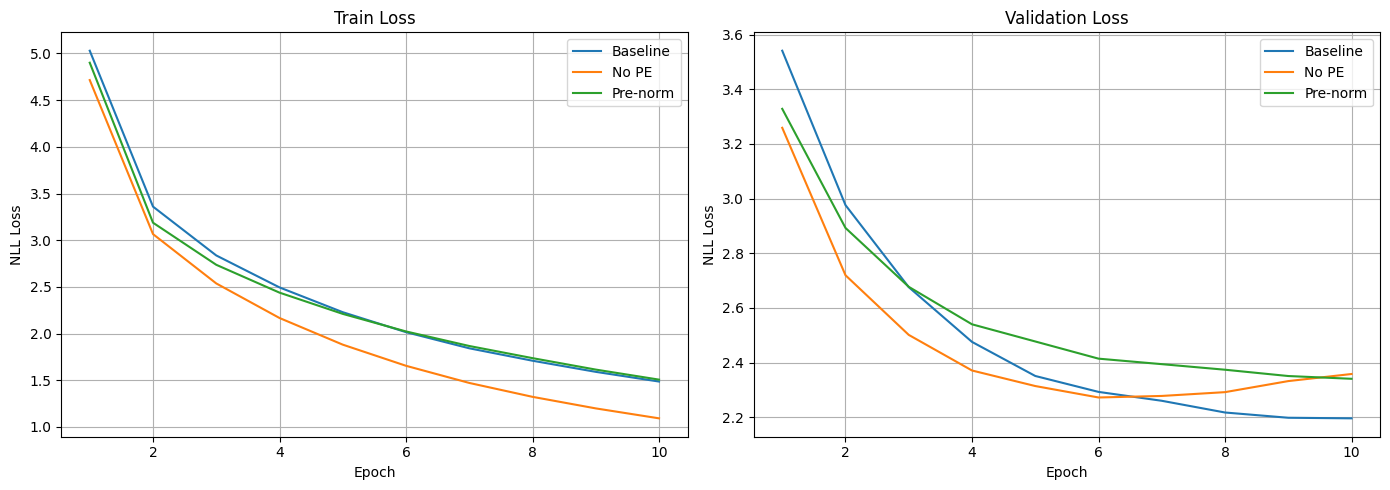

Loss curves saved to loss_curves.png


In [ ]:
import matplotlib.pyplot as plt

# --- BLEU scores ---
ckpt = torch.load('checkpoints_no_pe/best.pt', map_location=DEVICE)
no_pe_model.load_state_dict(ckpt['model_state_dict'])
bleu_no_pe, _, _ = run_evaluation(no_pe_model, val_loader, tokenizer_tgt, SEQ_LEN, DEVICE, num_examples_to_print=0)

ckpt = torch.load('checkpoints_prenorm/best.pt', map_location=DEVICE)
prenorm_model.load_state_dict(ckpt['model_state_dict'])
bleu_prenorm, _, _ = run_evaluation(prenorm_model, val_loader, tokenizer_tgt, SEQ_LEN, DEVICE, num_examples_to_print=0)

print('\n=== BLEU Score Comparison ===')
print(f'Baseline  (post-norm + PE):  {bleu_baseline:.2f}')
print(f'No PE     (post-norm, no PE): {bleu_no_pe:.2f}')
print(f'Pre-norm  (pre-norm  + PE):  {bleu_prenorm:.2f}')

# --- Loss curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = [h['epoch'] for h in baseline_history]

ax1.plot(epochs, [h['train_loss'] for h in baseline_history], label='Baseline')
ax1.plot(epochs, [h['train_loss'] for h in no_pe_history],   label='No PE')
ax1.plot(epochs, [h['train_loss'] for h in prenorm_history],  label='Pre-norm')
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, [h['val_loss'] for h in baseline_history], label='Baseline')
ax2.plot(epochs, [h['val_loss'] for h in no_pe_history],   label='No PE')
ax2.plot(epochs, [h['val_loss'] for h in prenorm_history],  label='Pre-norm')
ax2.set_title('Validation Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('NLL Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()
print('Loss curves saved to loss_curves.png')